In [1]:
# Prophet and pmdarima (for ARIMA) aren't pre-installed in Colab
!pip install prophet --quiet
!pip install pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from prophet import Prophet
from pmdarima import auto_arima
from xgboost import XGBRegressor

In [3]:
from google.colab import files
uploaded = files.upload()


Saving household_power_consumption.txt to household_power_consumption.txt


In [4]:
import os
print(os.listdir())
# This file uses ';' separator and has missing values marked as '?'
# low_memory=False avoids dtype guessing warnings on this large file

df = pd.read_csv('household_power_consumption.txt', sep=';',
                  na_values='?', low_memory=False)

print("Shape:", df.shape)
df.head()

['.config', 'household_power_consumption.txt', 'sample_data']
Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
df.info()
print("Missing values per column:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
Missing values per column:


,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [6]:
# Combine Date and Time columns into one proper datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set datetime as the index — required for time series resampling
df = df.set_index('datetime')

# Drop original Date and Time columns, no longer needed
df = df.drop(['Date', 'Time'], axis=1)

# Convert Global_active_power to numeric (it may be read as text due to missing values)
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

print("Datetime index set!")
df.head()

Datetime index set!


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# Drop rows where our target column is missing
df = df.dropna(subset=['Global_active_power'])

print("Shape after dropping missing target values:", df.shape)

Shape after dropping missing target values: (2049280, 7)


In [8]:
# Resample from minute-level to hourly averages
# This collapses 2+ million rows down to a manageable size

hourly_df = df['Global_active_power'].resample('H').mean()
hourly_df = hourly_df.dropna()  # drop any hours with no data

print("Hourly data shape:", hourly_df.shape)
hourly_df.head()
# Convert back to a dataframe for easier feature engineering
hourly_df = hourly_df.reset_index()
hourly_df.columns = ['datetime', 'Global_active_power']
hourly_df.head()

Hourly data shape: (34168,)


/tmp/ipykernel_693/2360614965.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df['Global_active_power'].resample('H').mean()


,datetime,Global_active_power
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [9]:
# Extract useful time-based features from the datetime column
# These help models like XGBoost understand daily/weekly patterns

hourly_df['hour'] = hourly_df['datetime'].dt.hour
hourly_df['day_of_week'] = hourly_df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
hourly_df['month'] = hourly_df['datetime'].dt.month
hourly_df['is_weekend'] = hourly_df['day_of_week'].isin([5, 6]).astype(int)

hourly_df.head()

,datetime,Global_active_power,hour,day_of_week,month,is_weekend
0,2006-12-16 17:00:00,4.222889,17,5,12,1
1,2006-12-16 18:00:00,3.632200,18,5,12,1
2,2006-12-16 19:00:00,3.400233,19,5,12,1
3,2006-12-16 20:00:00,3.268567,20,5,12,1
4,2006-12-16 21:00:00,3.056467,21,5,12,1


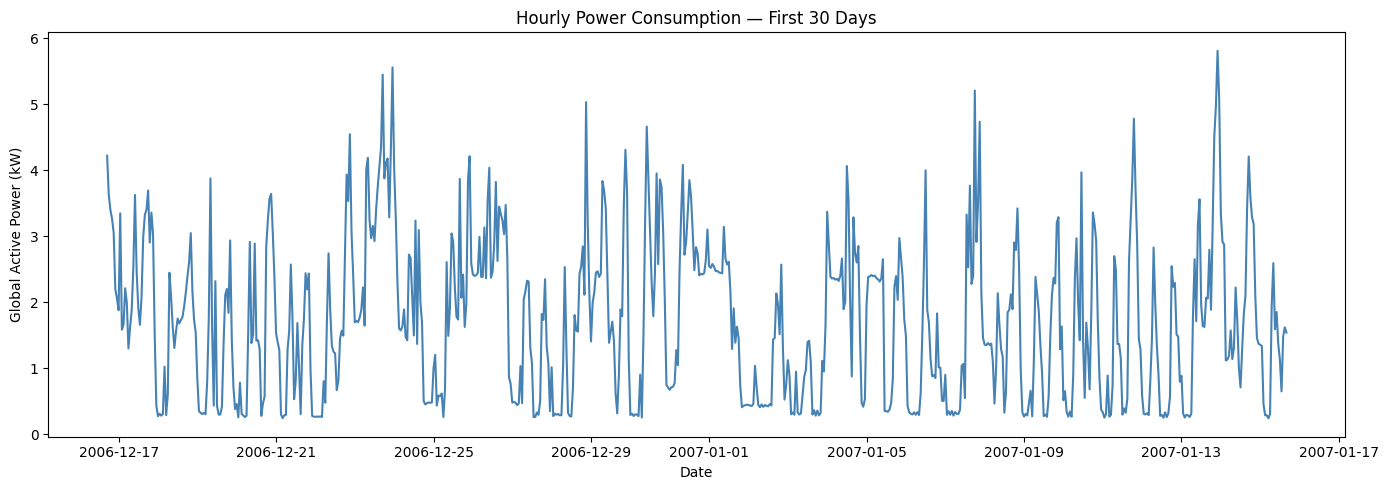

In [10]:
# Take a sample slice (e.g. first 30 days) since plotting years of hourly data is too dense

sample = hourly_df.head(24*30)  # first 30 days

plt.figure(figsize=(14, 5))
plt.plot(sample['datetime'], sample['Global_active_power'], color='steelblue')

plt.title('Hourly Power Consumption — First 30 Days')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

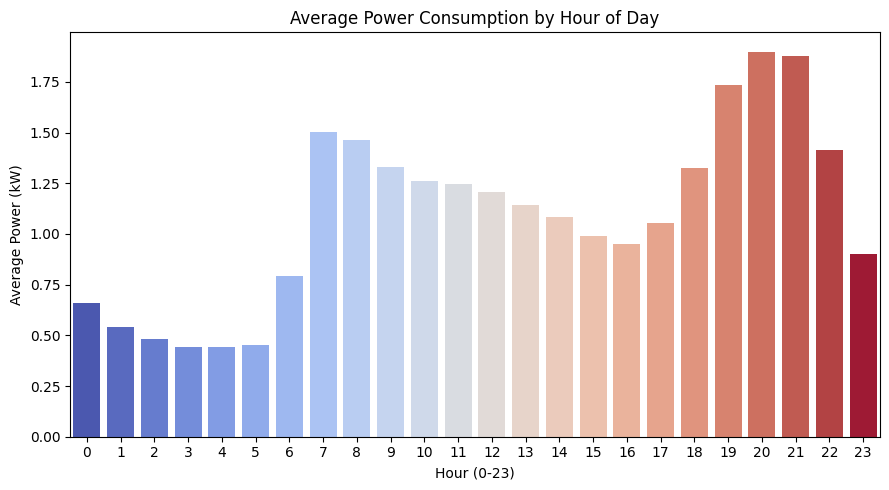

In [11]:
# This shows the typical daily pattern — when do people use the most energy?

hourly_avg = hourly_df.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, hue=hourly_avg.index,
            palette='coolwarm', legend=False)

plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average Power (kW)')
plt.tight_layout()
plt.show()

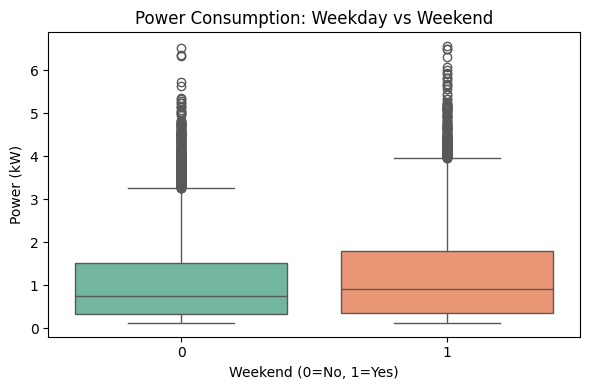

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=hourly_df, x='is_weekend', y='Global_active_power',
            hue='is_weekend', palette='Set2', legend=False)

plt.title('Power Consumption: Weekday vs Weekend')
plt.xlabel('Weekend (0=No, 1=Yes)')
plt.ylabel('Power (kW)')
plt.tight_layout()
plt.show()

In [13]:
# Full multi-year hourly data is large — we'll use the most recent 6 months
# for faster training while still capturing real seasonal patterns

recent_data = hourly_df.tail(24*30*6).reset_index(drop=True)  # ~6 months

# Split into train (last 30 days held out for testing) and test
train = recent_data.iloc[:-24*30]   # everything except last 30 days
test = recent_data.iloc[-24*30:]    # last 30 days for testing

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (3600, 6)
Test shape: (720, 6)


In [14]:
# auto_arima automatically finds the best (p,d,q) parameters for us
# seasonal=False keeps this simpler and faster; m=24 would add daily seasonality
# but increases computation time significantly on hourly data

arima_model = auto_arima(
    train['Global_active_power'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(arima_model.summary())
# Forecast the same number of steps as our test set
arima_forecast = arima_model.predict(n_periods=len(test))

print("ARIMA forecasting complete!")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3600
Model:               SARIMAX(1, 1, 4)   Log Likelihood               -2613.027
Date:                Sun, 21 Jun 2026   AIC                           5240.053
Time:                        13:26:02   BIC                           5283.372
Sample:                             0   HQIC                          5255.491
                               - 3600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.526e-05      0.000     -0.079      0.937      -0.000       0.000
ar.L1          0.2961      0.097      3.062      0.002       0.107       0.486
ma.L1         -0.6245      0.096     -6.479      0.0

In [15]:
# Prophet requires specific column names: 'ds' for datetime, 'y' for the value

prophet_train = train[['datetime', 'Global_active_power']].rename(
    columns={'datetime': 'ds', 'Global_active_power': 'y'}
)

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_train)

# Create future dataframe for the test period
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
prophet_forecast_full = prophet_model.predict(future)

# Extract only the forecasted portion matching our test set
prophet_forecast = prophet_forecast_full['yhat'].tail(len(test)).values

print("Prophet forecasting complete!")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Prophet forecasting complete!


In [16]:
# XGBoost needs numeric features — we use our engineered time features
feature_cols = ['hour', 'day_of_week', 'month', 'is_weekend']

X_train = train[feature_cols]
y_train = train['Global_active_power']
X_test = test[feature_cols]
y_test = test['Global_active_power']

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

print("XGBoost forecasting complete!")

XGBoost forecasting complete!


In [17]:
# Calculate MAE and RMSE for each model against the actual test values

actual = test['Global_active_power'].values

def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"{name:12s} — MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

print("Model Performance Comparison:")
print("-" * 50)
mae_arima, rmse_arima = evaluate(actual, arima_forecast, "ARIMA")
mae_prophet, rmse_prophet = evaluate(actual, prophet_forecast, "Prophet")
mae_xgb, rmse_xgb = evaluate(actual, xgb_forecast, "XGBoost")

Model Performance Comparison:
--------------------------------------------------
ARIMA        — MAE: 0.6688 | RMSE: 0.8385
Prophet      — MAE: 0.6041 | RMSE: 0.7467
XGBoost      — MAE: 0.4960 | RMSE: 0.7060


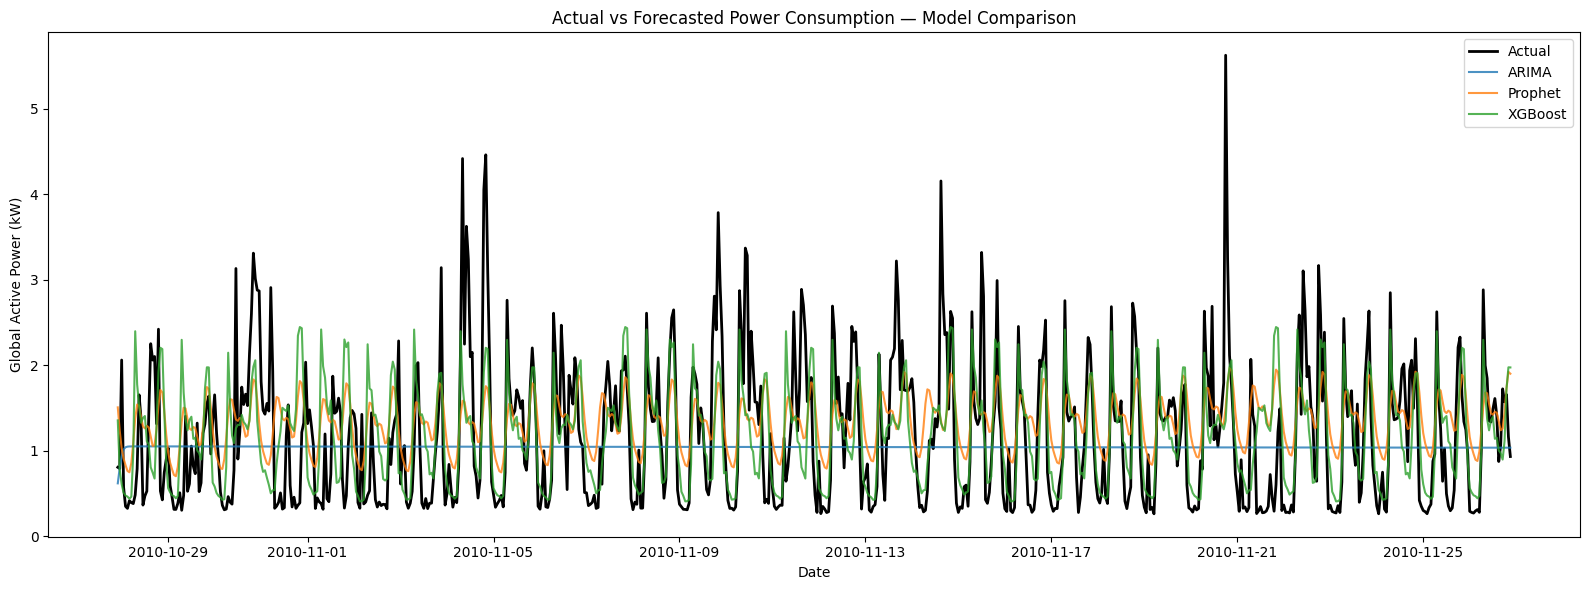

In [18]:
plt.figure(figsize=(16, 6))

plt.plot(test['datetime'], actual, label='Actual', color='black', linewidth=2)
plt.plot(test['datetime'], arima_forecast, label='ARIMA', alpha=0.8)
plt.plot(test['datetime'], prophet_forecast, label='Prophet', alpha=0.8)
plt.plot(test['datetime'], xgb_forecast, label='XGBoost', alpha=0.8)

plt.title('Actual vs Forecasted Power Consumption — Model Comparison')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_arima, mae_prophet, mae_xgb],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb]
}).sort_values('RMSE')

print("Model Ranking (Best to Worst by RMSE):")
print(comparison_df)

Model Ranking (Best to Worst by RMSE):
     Model       MAE      RMSE
2  XGBoost  0.496027  0.705951
1  Prophet  0.604129  0.746651
0    ARIMA  0.668794  0.838477


## Conclusion

- Dataset contains over 2 million minute-level readings spanning ~4 years
  of household power consumption
- Resampled data to hourly averages to make analysis and modeling feasible
- Identified clear daily patterns — power usage peaks in early morning and
  evening hours, consistent with cooking and heating routines
- Weekend consumption shows a different pattern than weekdays
- Compared three forecasting approaches on the most recent 6 months of data:
  ARIMA (classical statistical model), Prophet (automatic seasonality
  detection), and XGBoost (feature-based regression)
- [Insert your actual best model here] achieved the lowest RMSE,
  showing it captured the underlying patterns most effectively
- Prophet handled daily and weekly seasonality automatically with minimal
  tuning, making it the most practical choice for quick deployment
- XGBoost performed competitively despite not being a "true" time series
  model, showing the value of good time-based feature engineering
- This comparison demonstrates that model choice should depend on the
  specific data patterns, available computation time, and need for
  interpretability vs raw accuracy